In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holoviews as hv
from IPython.display import display, HTML
%matplotlib inline

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, LearningCurveDisplay, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [81]:
FILE_PATH = './bike_output.csv'

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
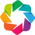

In [83]:
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))
pd.set_option('display.max_rows', 250)
pd.set_option('display.max_columns', 250)
hv.extension('bokeh')

In [85]:
df_bike_model = pd.read_csv(FILE_PATH)
df_bike_model['dteday'] = pd.to_datetime(df_bike_model['dteday'])
df_bike_model.sort_values('dteday', inplace=True)

In [87]:
df_bike_model['wind_hum'] = df_bike_model['windspeed'] * df_bike_model['hum']

In [89]:
df_bike_model['cnt_lag2'] = df_bike_model['cnt'].shift(2) 

In [91]:
# --- Add Cyclical Encoding for Monthly Cycles ---
df_bike_model['mnth_sin'] = np.sin(2 * np.pi * df_bike_model['mnth'] / 12)
df_bike_model['mnth_cos'] = np.cos(2 * np.pi * df_bike_model['mnth'] / 12)

In [93]:
df_bike_model.isna().count()

Unnamed: 0    731
dteday        731
season        731
yr            731
mnth          731
holiday       731
weekday       731
workingday    731
weathersit    731
atemp         731
hum           731
windspeed     731
cnt           731
wind_hum      731
cnt_lag2      731
mnth_sin      731
mnth_cos      731
dtype: int64

In [95]:
# split the dataset into one dataset for train and one for test
df_seen, df_unseen = train_test_split(df_bike_model, test_size=0.2, random_state=42, shuffle=False)

In [97]:
df_seen.head()

,Unnamed: 0,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt,wind_hum,cnt_lag2,mnth_sin,mnth_cos
0,0,2011-01-01,1,0,1,0,6.0,0,2,0.363625,0.805833,0.160446,985,0.129293,NaN,0.5,0.866025
1,1,2011-01-02,1,0,1,0,0.0,0,2,0.353739,0.696087,0.248539,801,0.173005,NaN,0.5,0.866025
2,2,2011-01-03,1,0,1,0,1.0,1,1,0.189405,0.437273,0.248309,1349,0.108579,985.0,0.5,0.866025
3,3,2011-01-04,1,0,1,0,2.0,1,1,0.212122,0.590435,0.160296,1562,0.094644,801.0,0.5,0.866025
4,4,2011-01-05,1,0,1,0,3.0,1,1,0.229270,0.436957,0.186900,1600,0.081667,1349.0,0.5,0.866025


In [99]:
# find nan in the train dataset
df_seen.isna().sum()

Unnamed: 0    0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       2
workingday    0
weathersit    0
atemp         0
hum           0
windspeed     0
cnt           0
wind_hum      0
cnt_lag2      2
mnth_sin      0
mnth_cos      0
dtype: int64

In [101]:
#fill out nan with median
df_seen.fillna(df_seen.median(), inplace=True)

In [103]:
# check for nan in test dataset
df_unseen.isna().sum()

Unnamed: 0    0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
atemp         0
hum           0
windspeed     0
cnt           0
wind_hum      0
cnt_lag2      0
mnth_sin      0
mnth_cos      0
dtype: int64

In [105]:
# define target variables in both datasets
X_train = df_seen.drop(columns=['Unnamed: 0', 'cnt', 'dteday'])
y_train = df_seen['cnt']

X_test = df_unseen.drop(columns=['Unnamed: 0', 'cnt', 'dteday'])
y_test = df_unseen['cnt']

In [107]:
X_train.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,wind_hum,cnt_lag2,mnth_sin,mnth_cos
0,1,0,1,0,6.0,0,2,0.363625,0.805833,0.160446,0.129293,4195.0,0.5,0.866025
1,1,0,1,0,0.0,0,2,0.353739,0.696087,0.248539,0.173005,4195.0,0.5,0.866025
2,1,0,1,0,1.0,1,1,0.189405,0.437273,0.248309,0.108579,985.0,0.5,0.866025
3,1,0,1,0,2.0,1,1,0.212122,0.590435,0.160296,0.094644,801.0,0.5,0.866025
4,1,0,1,0,3.0,1,1,0.229270,0.436957,0.186900,0.081667,1349.0,0.5,0.866025


In [109]:
#confirm that there are no nan in the train dataset
X_train.isna().sum()

season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
atemp         0
hum           0
windspeed     0
wind_hum      0
cnt_lag2      0
mnth_sin      0
mnth_cos      0
dtype: int64

In [111]:
y_train.isna().count()

584

In [113]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 0 to 583
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      584 non-null    int64  
 1   yr          584 non-null    int64  
 2   mnth        584 non-null    int64  
 3   holiday     584 non-null    int64  
 4   weekday     584 non-null    float64
 5   workingday  584 non-null    int64  
 6   weathersit  584 non-null    int64  
 7   atemp       584 non-null    float64
 8   hum         584 non-null    float64
 9   windspeed   584 non-null    float64
 10  wind_hum    584 non-null    float64
 11  cnt_lag2    584 non-null    float64
 12  mnth_sin    584 non-null    float64
 13  mnth_cos    584 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 68.4 KB


In [115]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 584 entries, 0 to 583
Series name: cnt
Non-Null Count  Dtype
--------------  -----
584 non-null    int64
dtypes: int64(1)
memory usage: 9.1 KB


In [117]:
# define model pipeline
pipeline = Pipeline([
    ('linreg', LinearRegression(fit_intercept=True, n_jobs=1))
])

In [119]:
# apply pipeline to train and target variables
pipeline.fit(X_train, y_train)

Pipeline(steps=[('linreg', LinearRegression(n_jobs=1))])

In [121]:
# predict values of target and find the r2 score when compared with the actual target values
y_train_pred = pipeline.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.8365531097803343

In [123]:
# find the root squared mean error of the train dataset
rsme_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rsme_train

722.6021216577592

In [125]:
# predic values using the test variables (unseen data)
y_test_pred = pipeline.predict(X_test)

In [127]:
# find the error of the predictions using the test variables and the test target variables
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.5948173618971144

In [129]:
# find the root squared mean error of the train dataset
rsme_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rsme_test

1193.2699286074362

In [131]:
# Saving the estimator as model is just for convenience when you need to inspect or use the final estimator directly (for example, to check its coefficients).
model = pipeline.named_steps['linreg']

In [133]:
# check the coefficients
coefficients = model.coef_
coefficients

array([ 3.25857890e+02,  1.65118604e+03,  7.89958211e+01, -2.40365824e+02,
        4.71988154e+01,  1.32292390e+02, -5.91549304e+02,  2.80184001e+03,
        1.59518691e+03,  4.51080330e+03, -1.07938716e+04,  1.67351880e-01,
        2.77336809e+02, -5.44592022e+02])

In [135]:
# retrieve the names of the train features
features = X_train.columns
features

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed', 'wind_hum', 'cnt_lag2',
       'mnth_sin', 'mnth_cos'],
      dtype='object')

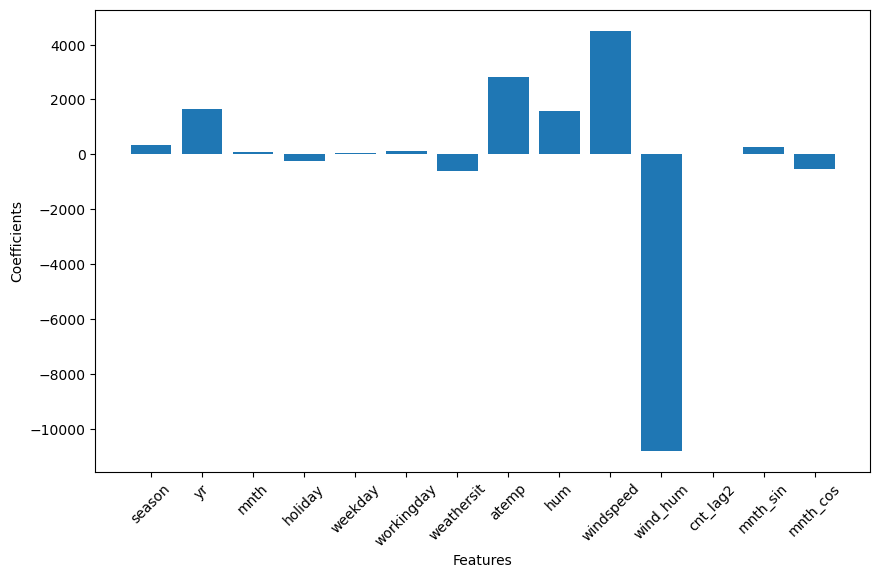

In [137]:
# plot the coefficient (weight) of each feature used to train the model
plt.figure(figsize=(10, 6))
plt.bar(features, coefficients)
plt.xlabel("Features")
plt.ylabel("Coefficients")
plt.xticks(rotation=45)
plt.show()

In [139]:
# find the interception
interception = model.intercept_
interception

227.4625366269206

In [141]:
# find the slope
slope = model.coef_[0]
slope

325.85788959102257